# Kantamal Catchment — CAMELS-IND Data Exploration

## Objective

This notebook extracts and explores hydrometeorological data for the
Kantamal gauging station in the Mahanadi/Tel River basin from the
CAMELS-IND dataset.

**CAMELS-IND Catchment ID:** 8013  
**Station:** Kantamal  
**Basin:** Mahanadi  
**Sub-basin:** Mahanadi/Tel

The notebook will examine:

- Observed streamflow
- Data availability and missing values
- Meteorological forcing variables
- Temporal coverage
- Variables suitable for streamflow forecasting

The processed data will later be used with LSTM, BiLSTM and Transformer models.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Path to CAMELS-IND observed streamflow data
streamflow_path = (
    "../data/camels_ind/"
    "CAMELS_IND_Catchments_Streamflow_Sufficient/"
    "streamflow_timeseries/"
    "streamflow_observed.csv"
)

# Load dataset
streamflow_raw = pd.read_csv(streamflow_path)

print("Dataset shape:", streamflow_raw.shape)
streamflow_raw.head()

Dataset shape: (14976, 245)


,year,month,day,3002,3005,3008,3009,3013,3014,3017,...,17005,17006,17007,17009,17011,17012,17015,17019,17022,17024
0,1980,1,1,NaN,23.2,36.1,NaN,NaN,NaN,NaN,...,2.00,3.8,NaN,NaN,12.2,2.7,0.8,23.7,10.3,18.0
1,1980,1,2,NaN,22.0,36.0,NaN,NaN,NaN,NaN,...,1.96,3.5,NaN,NaN,7.2,2.5,0.7,24.0,12.6,18.0
2,1980,1,3,NaN,21.4,36.0,NaN,NaN,NaN,NaN,...,2.22,3.1,NaN,NaN,5.8,2.1,0.0,30.0,5.8,16.0
3,1980,1,4,NaN,23.0,36.5,NaN,NaN,NaN,NaN,...,1.90,3.5,NaN,NaN,6.5,1.9,0.0,31.2,4.9,23.0
4,1980,1,5,NaN,22.2,36.7,NaN,NaN,NaN,NaN,...,1.90,3.9,NaN,NaN,5.6,1.5,0.0,32.7,5.2,16.0


In [24]:
KANTAMAL_ID = "8013"

# Make sure station IDs are treated as strings
streamflow_raw.columns = streamflow_raw.columns.astype(str)

# Construct a proper date column
streamflow_raw["date"] = pd.to_datetime(
    streamflow_raw[["year", "month", "day"]]
)

# Extract Kantamal
kantamal_flow = streamflow_raw[
    ["date", KANTAMAL_ID]
].copy()

kantamal_flow.rename(
    columns={KANTAMAL_ID: "streamflow"},
    inplace=True
)

kantamal_flow.head()

C:\Users\karthik\AppData\Local\Temp\ipykernel_1852\2135557490.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  streamflow_raw["date"] = pd.to_datetime(


,date,streamflow
0,1980-01-01,10.01
1,1980-01-02,9.73
2,1980-01-03,9.32
3,1980-01-04,12.29
4,1980-01-05,13.21


In [25]:
print("Start date:", kantamal_flow["date"].min())
print("End date:", kantamal_flow["date"].max())
print("Total days:", len(kantamal_flow))

print("\nMissing streamflow values:")
print(kantamal_flow["streamflow"].isna().sum())

print("\nAvailable observations:")
print(kantamal_flow["streamflow"].notna().sum())

missing_percent = (
    kantamal_flow["streamflow"].isna().mean() * 100
)

print(f"\nMissing percentage: {missing_percent:.2f}%")

Start date: 1980-01-01 00:00:00
End date: 2020-12-31 00:00:00
Total days: 14976

Missing streamflow values:
791

Available observations:
14185

Missing percentage: 5.28%


## Observed Streamflow Quality Assessment

Before preprocessing or model development, the observed Kantamal streamflow
record is examined for its temporal coverage, missing observations,
distribution, and possible anomalous values.

In [26]:
kantamal_flow["streamflow"].describe()

count    14185.000000
mean       348.106617
std        964.823076
min          0.000000
25%         22.920000
50%         82.330000
75%        255.520000
max      20000.000000
Name: streamflow, dtype: float64

In [27]:
missing_by_year = (
    kantamal_flow
    .assign(year=kantamal_flow["date"].dt.year)
    .groupby("year")["streamflow"]
    .apply(lambda x: x.isna().sum())
)

missing_by_year[missing_by_year > 0]

year
1980     30
1985     10
1989     28
1999     56
2018      2
2019    299
2020    366
Name: streamflow, dtype: int64

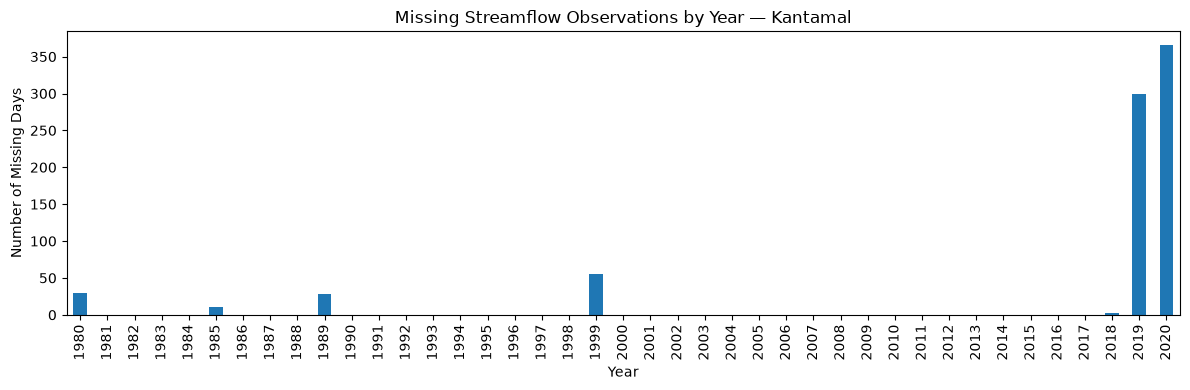

In [28]:
plt.figure(figsize=(12, 4))

missing_by_year.plot(kind="bar")

plt.title("Missing Streamflow Observations by Year — Kantamal")
plt.xlabel("Year")
plt.ylabel("Number of Missing Days")
plt.tight_layout()
plt.show()

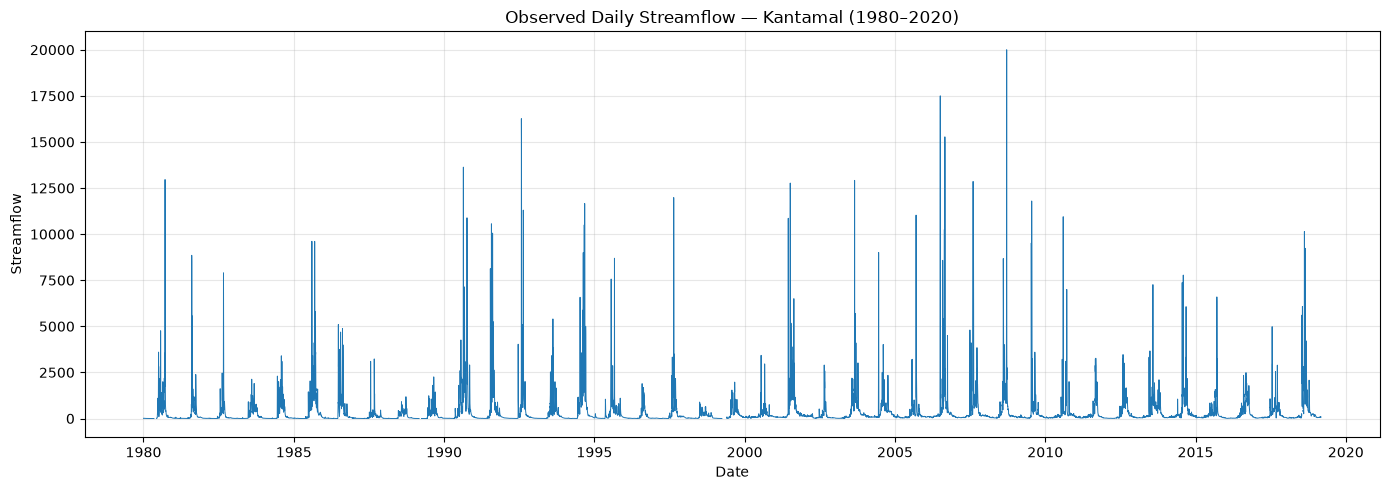

In [29]:
plt.figure(figsize=(14, 5))

plt.plot(
    kantamal_flow["date"],
    kantamal_flow["streamflow"],
    linewidth=0.7
)

plt.title("Observed Daily Streamflow — Kantamal (1980–2020)")
plt.xlabel("Date")
plt.ylabel("Streamflow")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
last_valid_date = kantamal_flow.loc[
    kantamal_flow["streamflow"].notna(),
    "date"
].max()

first_valid_date = kantamal_flow.loc[
    kantamal_flow["streamflow"].notna(),
    "date"
].min()

print("First valid observation:", first_valid_date)
print("Last valid observation:", last_valid_date)

First valid observation: 1980-01-01 00:00:00
Last valid observation: 2019-03-07 00:00:00


In [31]:
missing = kantamal_flow["streamflow"].isna()

gap_group = (missing != missing.shift()).cumsum()

missing_gaps = (
    kantamal_flow[missing]
    .groupby(gap_group[missing])
    .agg(
        start=("date", "min"),
        end=("date", "max"),
        days=("date", "size")
    )
)

missing_gaps.sort_values("days", ascending=False)

,start,end,days
streamflow,,,
14,2019-03-08,2020-12-31,665
8,1999-03-31,1999-05-25,56
2,1980-05-08,1980-06-06,30
6,1989-03-04,1989-03-31,28
4,1985-05-14,1985-05-23,10
10,2018-07-15,2018-07-15,1
12,2018-07-29,2018-07-29,1


In [32]:
kantamal_flow.nlargest(15, "streamflow")

,date,streamflow
10489,2008-09-19,20000.00
9682,2006-07-05,17500.00
4592,1992-07-28,16263.00
10488,2008-09-18,16000.00
9681,2006-07-04,15278.64
9738,2006-08-30,15276.24
4593,1992-07-29,15207.00
9739,2006-08-31,14900.00
3887,1990-08-23,13633.00
262,1980-09-19,12959.80


## Catchment-Mean Meteorological Forcings

CAMELS-IND provides daily catchment-averaged meteorological forcing data for
Kantamal (Catchment ID 8013). These variables will be examined as potential
predictors of daily streamflow.

In [33]:
forcing_path = (
    "../data/camels_ind/"
    "CAMELS_IND_Catchments_Streamflow_Sufficient/"
    "catchment_mean_forcings/"
    "08013.csv"
)

forcing_raw = pd.read_csv(forcing_path)

print("Dataset shape:", forcing_raw.shape)

print("\nColumns:")
for col in forcing_raw.columns:
    print(col)

Dataset shape: (14976, 22)

Columns:
year
month
day
prcp(mm/day)
tmax(C)
tmin(C)
tavg(C)
srad_lw(w/m2)
srad_sw(w/m2)
wind_u(m/s)
wind_v(m/s)
wind(m/s)
rel_hum(%)
pet(mm/day)
pet_gleam(mm/day)
aet_gleam(mm/day)
evap_canopy(mm/day)
evap_surface(mm/day)
sm_lvl1(kg/m2)
sm_lvl2(kg/m2)
sm_lvl3(kg/m2)
sm_lvl4(kg/m2)


In [34]:
# Construct date for the forcing dataset
forcing_raw["date"] = pd.to_datetime(
    forcing_raw[["year", "month", "day"]]
)

# Remove separate date-component columns
forcing = forcing_raw.drop(
    columns=["year", "month", "day"]
).copy()

# Put date first
forcing = forcing[
    ["date"] + [col for col in forcing.columns if col != "date"]
]

# Merge meteorological forcings with observed Kantamal streamflow
kantamal_data = pd.merge(
    forcing,
    kantamal_flow,
    on="date",
    how="inner"
)

print("Merged dataset shape:", kantamal_data.shape)
print("Start date:", kantamal_data["date"].min())
print("End date:", kantamal_data["date"].max())

kantamal_data.head()

Merged dataset shape: (14976, 21)
Start date: 1980-01-01 00:00:00
End date: 2020-12-31 00:00:00


,date,prcp(mm/day),tmax(C),tmin(C),tavg(C),srad_lw(w/m2),srad_sw(w/m2),wind_u(m/s),wind_v(m/s),wind(m/s),...,pet(mm/day),pet_gleam(mm/day),aet_gleam(mm/day),evap_canopy(mm/day),evap_surface(mm/day),sm_lvl1(kg/m2),sm_lvl2(kg/m2),sm_lvl3(kg/m2),sm_lvl4(kg/m2),streamflow
0,1980-01-01,0.00,29.14,15.07,22.10,351.17,258.53,0.70,1.08,1.29,...,NaN,2.29,1.27,0.00,0.53,3.27,56.85,162.90,510.57,10.01
1,1980-01-02,0.00,29.52,16.69,23.10,366.71,253.43,0.86,0.31,0.91,...,NaN,2.23,1.32,0.03,0.49,3.20,56.73,162.62,510.38,9.73
2,1980-01-03,0.41,29.37,16.85,23.11,369.43,244.62,0.55,-0.30,0.63,...,NaN,1.81,1.09,0.28,0.48,3.21,56.61,162.33,510.16,9.32
3,1980-01-04,0.48,28.61,17.13,22.87,374.26,205.42,-1.02,-0.80,1.30,...,NaN,1.82,1.27,0.35,0.51,3.54,56.49,162.06,509.98,12.29
4,1980-01-05,1.18,25.77,16.69,21.23,372.31,243.53,-0.74,-0.04,0.74,...,NaN,1.84,1.29,0.31,0.55,3.76,56.37,161.78,509.79,13.21


In [35]:
missing_summary = pd.DataFrame({
    "missing_count": kantamal_data.isna().sum(),
    "missing_percent": kantamal_data.isna().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_percent",
    ascending=False
)

missing_summary

,missing_count,missing_percent
streamflow,791,5.281784
pet(mm/day),366,2.443910


In [36]:
kantamal_data.drop(
    columns=["date"]
).describe().T

,count,mean,std,min,25%,50%,75%,max
prcp(mm/day),14976.0,3.817261,10.154390,0.00,0.0000,0.100,3.3000,195.08
tmax(C),14976.0,32.477773,4.132507,19.43,29.4900,31.610,35.1600,43.93
tmin(C),14976.0,20.561969,4.664860,0.00,16.7500,22.350,24.0500,30.17
tavg(C),14976.0,26.519848,4.036627,13.44,23.5375,26.940,28.8700,36.82
srad_lw(w/m2),14976.0,388.671681,41.254693,269.18,354.9825,400.245,425.2100,459.02
srad_sw(w/m2),14976.0,283.718406,64.767941,14.99,257.6200,288.200,329.7725,411.68
wind_u(m/s),14976.0,0.677424,1.399734,-7.10,-0.3500,0.470,1.6200,6.18
wind_v(m/s),14976.0,0.126454,1.198397,-7.98,-0.8400,-0.010,0.9900,5.80
wind(m/s),14976.0,1.793876,0.977471,0.04,1.1000,1.520,2.2700,8.25
rel_hum(%),14976.0,59.594361,20.057950,13.94,43.4575,58.775,78.2400,96.79


In [37]:
pet_missing = kantamal_data.loc[
    kantamal_data["pet(mm/day)"].isna(),
    "date"
]

print("First missing PET:", pet_missing.min())
print("Last missing PET:", pet_missing.max())
print("Number missing:", len(pet_missing))

print("\nMissing PET by year:")
print(pet_missing.dt.year.value_counts().sort_index())

First missing PET: 1980-01-01 00:00:00
Last missing PET: 1980-12-31 00:00:00
Number missing: 366

Missing PET by year:
date
1980    366
Name: count, dtype: int64


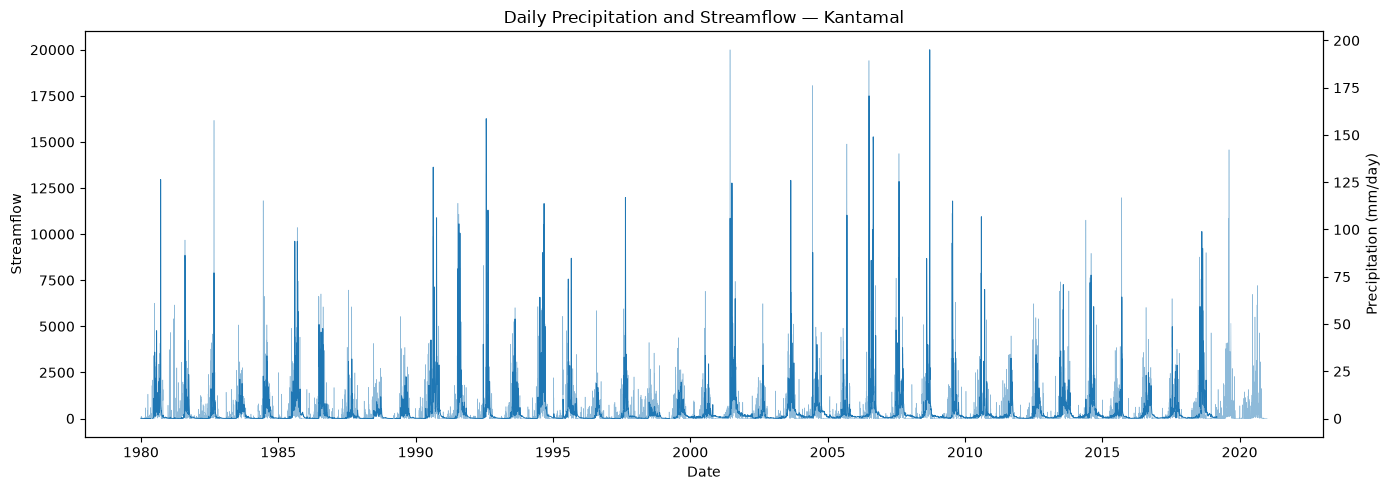

In [38]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    kantamal_data["date"],
    kantamal_data["streamflow"],
    linewidth=0.7,
    label="Streamflow"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Streamflow")

ax2 = ax1.twinx()

ax2.plot(
    kantamal_data["date"],
    kantamal_data["prcp(mm/day)"],
    linewidth=0.4,
    alpha=0.5,
    label="Precipitation"
)

ax2.set_ylabel("Precipitation (mm/day)")

plt.title("Daily Precipitation and Streamflow — Kantamal")
plt.tight_layout()
plt.show()

In [39]:
selected_features = [
    "date",
    "prcp(mm/day)",
    "tavg(C)",
    "pet_gleam(mm/day)",
    "sm_lvl1(kg/m2)",
    "sm_lvl2(kg/m2)",
    "streamflow"
]

kantamal_selected = kantamal_data[
    selected_features
].copy()

kantamal_selected.head()

,date,prcp(mm/day),tavg(C),pet_gleam(mm/day),sm_lvl1(kg/m2),sm_lvl2(kg/m2),streamflow
0,1980-01-01,0.00,22.10,2.29,3.27,56.85,10.01
1,1980-01-02,0.00,23.10,2.23,3.20,56.73,9.73
2,1980-01-03,0.41,23.11,1.81,3.21,56.61,9.32
3,1980-01-04,0.48,22.87,1.82,3.54,56.49,12.29
4,1980-01-05,1.18,21.23,1.84,3.76,56.37,13.21


## Gap-Aware Sequence Preparation

The forecasting task is formulated as **one-day-ahead streamflow prediction**.

For each prediction, the model uses the previous **30 consecutive days** of
hydrometeorological conditions and streamflow to predict streamflow on the
following day.

Windows containing missing streamflow observations or discontinuous dates are
excluded rather than interpolating long observational gaps.

In [40]:
FEATURES = [
    "prcp(mm/day)",
    "tavg(C)",
    "pet_gleam(mm/day)",
    "sm_lvl1(kg/m2)",
    "sm_lvl2(kg/m2)",
    "streamflow"
]

TARGET = "streamflow"
LOOKBACK = 30


def create_gap_aware_sequences(data, features, target, lookback=30):
    X = []
    y = []
    target_dates = []

    for i in range(lookback, len(data)):

        window = data.iloc[i - lookback:i]
        target_row = data.iloc[i]

        # The input and target must contain no missing values
        if window[features].isna().any().any():
            continue

        if pd.isna(target_row[target]):
            continue

        # All dates from the beginning of the window through
        # the target day must be consecutive calendar days.
        expected_days = lookback + 1

        actual_days = (
            target_row["date"] - window.iloc[0]["date"]
        ).days + 1

        if actual_days != expected_days:
            continue

        X.append(window[features].to_numpy(dtype=float))
        y.append(float(target_row[target]))
        target_dates.append(target_row["date"])

    return (
        np.array(X),
        np.array(y),
        np.array(target_dates)
    )


X, y, target_dates = create_gap_aware_sequences(
    kantamal_selected,
    FEATURES,
    TARGET,
    LOOKBACK
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst target date:", target_dates[0])
print("Last target date:", target_dates[-1])

X shape: (13992, 30, 6)
y shape: (13992,)

First target date: 1980-01-31 00:00:00
Last target date: 2019-03-07 00:00:00


In [41]:
# Dates immediately after known streamflow gaps
gap_end_dates = [
    pd.Timestamp("1980-06-07"),
    pd.Timestamp("1985-05-24"),
    pd.Timestamp("1989-04-01"),
    pd.Timestamp("1999-05-26"),
    pd.Timestamp("2018-07-16"),
    pd.Timestamp("2018-07-30")
]

print("Checking predictions immediately after missing-data gaps:\n")

for date in gap_end_dates:
    present = date.to_datetime64() in target_dates
    print(date.date(), "->", present)

Checking predictions immediately after missing-data gaps:

1980-06-07 -> False
1985-05-24 -> False
1989-04-01 -> False
1999-05-26 -> False
2018-07-16 -> False
2018-07-30 -> False


In [42]:
for gap_end in gap_end_dates:
    later_dates = target_dates[
        target_dates > gap_end.to_datetime64()
    ]

    if len(later_dates) > 0:
        print(
            f"After {gap_end.date()} -> "
            f"first valid target: "
            f"{pd.Timestamp(later_dates[0]).date()}"
        )

After 1980-06-07 -> first valid target: 1980-07-07
After 1985-05-24 -> first valid target: 1985-06-23
After 1989-04-01 -> first valid target: 1989-05-01
After 1999-05-26 -> first valid target: 1999-06-25
After 2018-07-16 -> first valid target: 2018-08-29
After 2018-07-30 -> first valid target: 2018-08-29


## Chronological Train–Validation–Test Split

Valid gap-aware sequences are divided chronologically into training,
validation, and testing subsets.

- Training: 70%
- Validation: 15%
- Testing: 15%

Random shuffling is not used because future observations must not be used
to train models that predict earlier periods.

In [43]:
n_samples = len(X)

train_end = int(n_samples * 0.70)
val_end = int(n_samples * 0.85)

X_train = X[:train_end]
y_train = y[:train_end]
dates_train = target_dates[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]
dates_val = target_dates[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]
dates_test = target_dates[val_end:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

print("\nTRAIN")
print(pd.Timestamp(dates_train[0]).date(), "to",
      pd.Timestamp(dates_train[-1]).date())

print("\nVALIDATION")
print(pd.Timestamp(dates_val[0]).date(), "to",
      pd.Timestamp(dates_val[-1]).date())

print("\nTEST")
print(pd.Timestamp(dates_test[0]).date(), "to",
      pd.Timestamp(dates_test[-1]).date())

Training samples: 9794
Validation samples: 2099
Testing samples: 2099

TRAIN
1980-01-31 to 2007-07-25

VALIDATION
2007-07-26 to 2013-04-23

TEST
2013-04-24 to 2019-03-07


In [44]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

In [45]:
n_features = X_train.shape[2]

# Flatten training sequences:
# (samples, 30, 6) -> (samples × 30, 6)
X_train_2d = X_train.reshape(-1, n_features)

# Learn feature scaling ONLY from training data
feature_scaler.fit(X_train_2d)

# Transform each dataset using the same training-fitted scaler
X_train_scaled = feature_scaler.transform(
    X_train.reshape(-1, n_features)
).reshape(X_train.shape)

X_val_scaled = feature_scaler.transform(
    X_val.reshape(-1, n_features)
).reshape(X_val.shape)

X_test_scaled = feature_scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

In [47]:
target_scaler.fit(y_train.reshape(-1, 1))

y_train_scaled = target_scaler.transform(
    y_train.reshape(-1, 1)
).ravel()

y_val_scaled = target_scaler.transform(
    y_val.reshape(-1, 1)
).ravel()

y_test_scaled = target_scaler.transform(
    y_test.reshape(-1, 1)
).ravel()

In [48]:
print("X train:", X_train_scaled.shape)
print("X validation:", X_val_scaled.shape)
print("X test:", X_test_scaled.shape)

print("\ny train:", y_train_scaled.shape)
print("y validation:", y_val_scaled.shape)
print("y test:", y_test_scaled.shape)

print("\nTraining feature scaled min:",
      X_train_scaled.min(axis=(0, 1)))

print("Training feature scaled max:",
      X_train_scaled.max(axis=(0, 1)))

X train: (9794, 30, 6)
X validation: (2099, 30, 6)
X test: (2099, 30, 6)

y train: (9794,)
y validation: (2099,)
y test: (2099,)

Training feature scaled min: [0. 0. 0. 0. 0. 0.]
Training feature scaled max: [1. 1. 1. 1. 1. 1.]


## Multivariate LSTM Model

A multivariate LSTM is developed for one-day-ahead streamflow forecasting.

Each input sequence contains 30 consecutive days of:

- Precipitation
- Mean air temperature
- GLEAM potential evapotranspiration
- Soil moisture layer 1
- Soil moisture layer 2
- Observed streamflow

The model predicts streamflow for the following day.

In [58]:
import tensorflow as tf
LOOKBACK = 30
N_FEATURES = 6

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(LOOKBACK, N_FEATURES)),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation="relu"),

    tf.keras.layers.Dense(1)
])

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

In [61]:
history_lstm = lstm_model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=30,
    batch_size=32,
    shuffle=False,
    verbose=1
)

Epoch 1/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0029 - val_loss: 0.0026
Epoch 2/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 3/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 4/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 8.9447e-04 - val_loss: 0.0011
Epoch 5/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.5420e-04 - val_loss: 0.0010
Epoch 6/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.3914e-04 - val_loss: 8.5868e-04
Epoch 7/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.2324e-04 - val_loss: 8.9092e-04
Epoch 8/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.3250e-04 - val_loss: 8.4190e-04
Epoch 9/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.9879e-04 - val_loss: 9.4215e-04
Epoch 10/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.0546e-04 - val_loss: 7.5260e-04
Epoch 11/30
307/307 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.6034e-04 - val_loss: 7.1565e

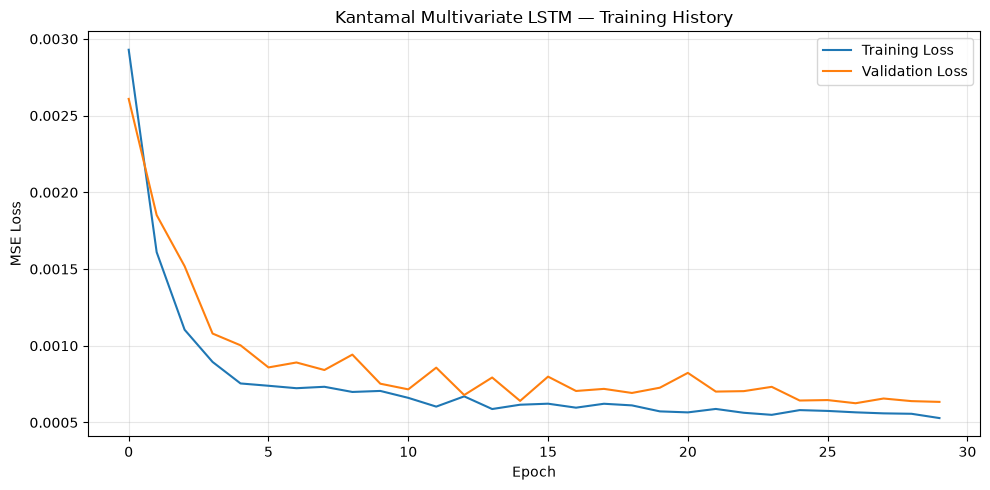

In [62]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Kantamal Multivariate LSTM — Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## LSTM Test-Set Evaluation

The trained LSTM is evaluated on the chronologically held-out test period
(2013-04-24 to 2019-03-07).

Predictions are transformed back to the original streamflow units before
calculating hydrological performance metrics.

In [63]:
# Predict normalized streamflow
y_pred_scaled = lstm_model.predict(
    X_test_scaled,
    verbose=0
)

# Convert predictions back to original streamflow units
y_pred_lstm = target_scaler.inverse_transform(
    y_pred_scaled
).ravel()

# y_test is already in original units
y_true = y_test.copy()

print("Predictions:", y_pred_lstm.shape)
print("Observations:", y_true.shape)

print("\nFirst 5 observed values:")
print(y_true[:5])

print("\nFirst 5 predicted values:")
print(y_pred_lstm[:5])

Predictions: (2099,)
Observations: (2099,)

First 5 observed values:
[114.   108.93 102.47  97.96 109.  ]

First 5 predicted values:
[152.32964 148.63708 143.44582 139.14522 135.57063]


In [64]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse_lstm = np.sqrt(
    mean_squared_error(y_true, y_pred_lstm)
)

mae_lstm = mean_absolute_error(
    y_true,
    y_pred_lstm
)

r2_lstm = r2_score(
    y_true,
    y_pred_lstm
)

nse_lstm = 1 - (
    np.sum((y_true - y_pred_lstm) ** 2)
    /
    np.sum((y_true - np.mean(y_true)) ** 2)
)

print("Kantamal Multivariate LSTM")
print("---------------------------")
print(f"RMSE : {rmse_lstm:.2f}")
print(f"MAE  : {mae_lstm:.2f}")
print(f"R²   : {r2_lstm:.4f}")
print(f"NSE  : {nse_lstm:.4f}")

Kantamal Multivariate LSTM
---------------------------
RMSE : 421.28
MAE  : 194.66
R²   : 0.5828
NSE  : 0.5828


In [65]:
STREAMFLOW_FEATURE_INDEX = FEATURES.index("streamflow")

persistence_pred = X_test[
    :, -1, STREAMFLOW_FEATURE_INDEX
]

In [66]:
rmse_persistence = np.sqrt(
    mean_squared_error(y_true, persistence_pred)
)

mae_persistence = mean_absolute_error(
    y_true,
    persistence_pred
)

r2_persistence = r2_score(
    y_true,
    persistence_pred
)

nse_persistence = 1 - (
    np.sum((y_true - persistence_pred) ** 2)
    /
    np.sum((y_true - np.mean(y_true)) ** 2)
)

print("Persistence Baseline")
print("--------------------")
print(f"RMSE : {rmse_persistence:.2f}")
print(f"MAE  : {mae_persistence:.2f}")
print(f"R²   : {r2_persistence:.4f}")
print(f"NSE  : {nse_persistence:.4f}")

Persistence Baseline
--------------------
RMSE : 436.22
MAE  : 109.61
R²   : 0.5526
NSE  : 0.5526


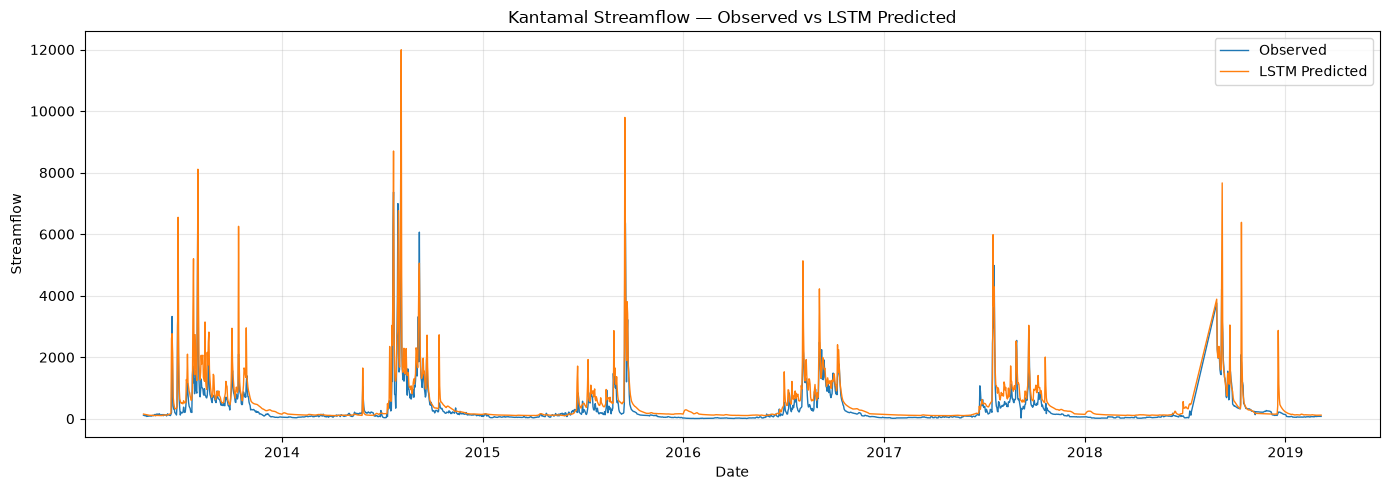

In [67]:
plt.figure(figsize=(14, 5))

plt.plot(
    dates_test,
    y_true,
    label="Observed",
    linewidth=1
)

plt.plot(
    dates_test,
    y_pred_lstm,
    label="LSTM Predicted",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Streamflow")
plt.title(
    "Kantamal Streamflow — Observed vs LSTM Predicted"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [68]:
# Identify high-flow days using the 95th percentile
high_flow_threshold = np.percentile(y_true, 95)

high_flow_mask = y_true >= high_flow_threshold

print(
    f"95th percentile threshold: "
    f"{high_flow_threshold:.2f}"
)

print(
    "Number of high-flow test days:",
    high_flow_mask.sum()
)

rmse_high = np.sqrt(
    mean_squared_error(
        y_true[high_flow_mask],
        y_pred_lstm[high_flow_mask]
    )
)

mae_high = mean_absolute_error(
    y_true[high_flow_mask],
    y_pred_lstm[high_flow_mask]
)

print(f"High-flow RMSE: {rmse_high:.2f}")
print(f"High-flow MAE : {mae_high:.2f}")

95th percentile threshold: 1317.01
Number of high-flow test days: 105
High-flow RMSE: 1438.43
High-flow MAE : 851.01


In [69]:
bias_lstm = np.mean(y_pred_lstm - y_true)

print(f"Mean prediction bias: {bias_lstm:.2f}")

print(
    "Observed mean:",
    round(np.mean(y_true), 2)
)

print(
    "Predicted mean:",
    round(np.mean(y_pred_lstm), 2)
)

Mean prediction bias: 163.81
Observed mean: 330.33
Predicted mean: 494.14
